# Phase 4 — SHAP Interpretation Layer (README §5.1, §9)

Turns the frozen Phase 3 forest into the project's actual deliverable: an
account of **why** a filer's effective rate lands where it does.

| §5.1 requirement | Where it is produced here |
|---|---|
| `TreeExplainer` on the Random Forest | Batch computed by `scripts/compute_shap.py`, loaded below |
| **Global** feature-importance summary | `mean_abs_shap` table + summary/beeswarm figure |
| **Global** dependence plots | One panel per headline feature |
| **Per-filer** waterfall, baseline → prediction, one labeled bar per feature | Archetype and random-sample waterfalls |

**Inputs are gated, not assumed.** The frozen CSVs are byte-verified against
`freeze_manifest.json`. The model artifact is verified *functionally* — matching
hyperparameters plus reproduction of the logged test metrics — because a joblib
file is not byte-reproducible across machines (see the note in
`scripts/compute_shap.py`).

**Batch scope (decision logged):** 4,000 filers drawn from the 12,247-row test
set with `random_state=42`. Exact TreeSHAP costs ~1.7 s/filer on this forest
(500 trees, 5.87M leaves, mean depth 42; cost scales with depth² per tree), so
the full test set would take ~6 hours for precision that does not change any
ranking or plot shape. Test deciles are equal-sized by construction, so a simple
random draw yields ~400 filers per income decile with no stratification bias.

**Scale reminder (§3.3):** every contribution below is in **effective-rate
percentage points**. `+1.5` means *pushes this filer's rate up 1.5 points*.

In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

ROOT = Path.cwd()
while not (ROOT / "README.md").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
PROCESSED, MODELS = ROOT / "data" / "processed", ROOT / "models"
SHAP_DIR, FIGURES = ROOT / "reports" / "shap", ROOT / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

manifest = json.loads((PROCESSED / "freeze_manifest.json").read_text())
metrics = json.loads((MODELS / "rf_metrics.json").read_text())
baseline_meta = json.loads((SHAP_DIR / "baseline.json").read_text())

model = joblib.load(MODELS / "rf_eff_rate.joblib")
rf, encoder = model.named_steps["rf"], model.named_steps["encode"]

FEATURE_COLS = manifest["feature_cols"]
BASELINE = baseline_meta["expected_value"]
ENCODED_COLS = baseline_meta["encoded_columns"]

shap_encoded = np.load(SHAP_DIR / "shap_values_encoded.npy")
X_encoded = np.load(SHAP_DIR / "X_encoded.npy")
X_raw = pd.read_csv(SHAP_DIR / "X_raw.csv")
sample_index = np.load(SHAP_DIR / "sample_index.npy")

test = pd.read_csv(PROCESSED / "test.csv")
actual = test.iloc[sample_index]["eff_rate"].to_numpy()
predicted = rf.predict(X_encoded)

print(f"SHAP matrix {shap_encoded.shape} over {len(X_raw):,} filers "
      f"({len(ENCODED_COLS)} encoded columns -> {len(FEATURE_COLS)} source features)")
print(f"Baseline (expected_value) = {BASELINE:.4f} rate points")
print(f"  cross-check: mean predicted rate over train = "
      f"{rf.predict(encoder.transform(pd.read_csv(PROCESSED / 'train.csv')[FEATURE_COLS])).mean():.4f}")

drift = np.abs(shap_encoded.sum(axis=1) + BASELINE - predicted).max()
print(f"\nAdditivity: max |baseline + sum(SHAP) - prediction| = {drift:.2e}")
assert drift < 1e-4, "additivity violated - SHAP output is not trustworthy"
print("Every waterfall below therefore closes exactly on the model's own prediction.")

SHAP matrix (4000, 73) over 4,000 filers (73 encoded columns -> 16 source features)
Baseline (expected_value) = 5.3103 rate points


  cross-check: mean predicted rate over train = 5.3090

Additivity: max |baseline + sum(SHAP) - prediction| = 5.01e-11
Every waterfall below therefore closes exactly on the model's own prediction.


## Collapsing 73 encoded columns back to the 16 source features

§5.1 asks for "one labeled bar **per feature**", and its example names real
features (*married-joint*, *2 dependents*, *dividend-heavy income*). The model
however sees 73 one-hot columns — 51 of them states. A waterfall with 51 state
bars would be unreadable and would also misstate the finding: `statefip_6`
carries no meaning on its own, *state* does.

Shapley values are **additive**, so the contribution of a group of columns is
the sum of their individual values. Summing each categorical's dummies is
therefore exact, not an approximation, and additivity survives the collapse.

The repo already contains a second implementation of this collapse —
`model_interface._collapse_encoded_contributions`, which the Streamlit page uses
for live explanations. It is reimplemented here independently from the encoder's
own column names and then **asserted equal** to that one, so Phase 4's analysis
and Phase 7's demo provably describe the same model.

In [2]:
CATEGORICAL = ["filing_status", "marst", "statefip"]
NUMERIC = [c for c in FEATURE_COLS if c not in CATEGORICAL]

# Map every encoded column to its source feature, derived from the encoder's own
# feature names rather than from an assumed ordering.
source_of = {}
for name in ENCODED_COLS:
    if name in FEATURE_COLS:
        source_of[name] = name                       # passthrough numeric
    else:
        parent = next(c for c in CATEGORICAL if name.startswith(c + "_"))
        source_of[name] = parent
assert set(source_of.values()) == set(FEATURE_COLS)

group_cols = {f: [i for i, n in enumerate(ENCODED_COLS) if source_of[n] == f]
              for f in FEATURE_COLS}
widths = {f: len(ix) for f, ix in group_cols.items()}
print("columns per source feature:",
      {k: v for k, v in widths.items() if v > 1}, "| rest = 1")

shap_collapsed = np.column_stack([shap_encoded[:, group_cols[f]].sum(axis=1)
                                  for f in FEATURE_COLS])
print(f"collapsed {shap_encoded.shape} -> {shap_collapsed.shape}")

drift = np.abs(shap_collapsed.sum(axis=1) + BASELINE - predicted).max()
print(f"additivity after collapse: {drift:.2e}")
assert drift < 1e-4

# Independent cross-check against the implementation the Streamlit page uses.
import sys
sys.path.insert(0, str(ROOT))
import model_interface as mi
theirs = mi._collapse_encoded_contributions(shap_encoded[0])
mine = dict(zip(FEATURE_COLS, shap_collapsed[0]))
delta = max(abs(theirs[c] - mine[c]) for c in FEATURE_COLS)
print(f"\nagreement with model_interface._collapse_encoded_contributions: "
      f"max diff {delta:.2e}")
assert delta < 1e-9, "Phase 4 and the Streamlit page disagree about the collapse"
print("Phase 4 analysis and the Phase 7 demo path collapse identically.")

columns per source feature: {'filing_status': 3, 'marst': 6, 'statefip': 51} | rest = 1
collapsed (4000, 73) -> (4000, 16)
additivity after collapse: 5.01e-11

agreement with model_interface._collapse_encoded_contributions: max diff 3.47e-18
Phase 4 analysis and the Phase 7 demo path collapse identically.


## Global output 1 — feature-importance summary (§5.1)

Mean |SHAP| per feature: the average absolute number of rate points a feature
moves a filer, across the sampled filers. This is the "which characteristics
matter" ranking.

It is reported next to Phase 3's impurity importances deliberately. Impurity
importance is biased toward high-cardinality features (`statefip` has 51 columns
to split on) and says nothing about *direction* or magnitude in rate points.
Mean |SHAP| is measured in the target's own units, which is what the equity
argument needs.

Global feature importance (rate points):
                     mean_abs_shap_pts  mean_signed_shap_pts  impurity_importance  shap_rank  impurity_rank
unit_inctot                     5.8995                0.3047               0.5166          1              1
filing_status                   3.3718               -0.1768               0.2183          2              2
nchild                          1.0394                0.1561               0.0716          3              3
wage_share                      0.6191               -0.1281               0.0252          4              6
age                             0.4961               -0.0075               0.0385          5              4
famsize                         0.4816               -0.0374               0.0242          6              7
interest_share                  0.4551               -0.0147               0.0308          7              5
marst                           0.4431                0.0090               0.0215          8   

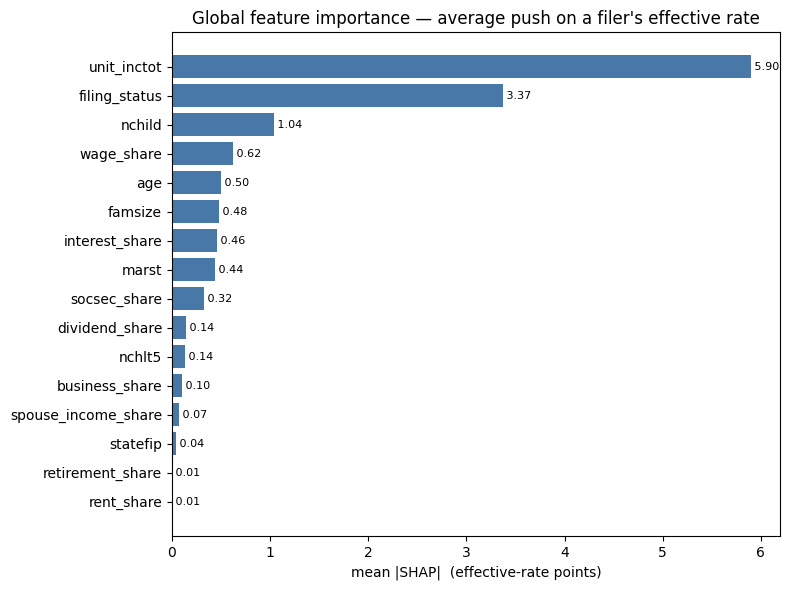

In [3]:
mean_abs = pd.Series(np.abs(shap_collapsed).mean(axis=0), index=FEATURE_COLS)
mean_signed = pd.Series(shap_collapsed.mean(axis=0), index=FEATURE_COLS)

imp_encoded = pd.Series(rf.feature_importances_, index=ENCODED_COLS)
imp_collapsed = pd.Series({f: imp_encoded.iloc[group_cols[f]].sum() for f in FEATURE_COLS})

summary = pd.DataFrame({
    "mean_abs_shap_pts": mean_abs,
    "mean_signed_shap_pts": mean_signed,
    "impurity_importance": imp_collapsed,
}).sort_values("mean_abs_shap_pts", ascending=False)
summary["shap_rank"] = range(1, len(summary) + 1)
summary["impurity_rank"] = summary["impurity_importance"].rank(ascending=False).astype(int)
print("Global feature importance (rate points):")
print(summary.round(4).to_string())
summary.to_csv(SHAP_DIR / "global_feature_importance.csv")

fig, ax = plt.subplots(figsize=(8, 6))
s = summary.sort_values("mean_abs_shap_pts")
ax.barh(s.index, s["mean_abs_shap_pts"], color="#4878a8")
ax.set_xlabel("mean |SHAP|  (effective-rate points)")
ax.set_title("Global feature importance — average push on a filer's effective rate")
for y, v in enumerate(s["mean_abs_shap_pts"]):
    ax.text(v, y, f" {v:.2f}", va="center", fontsize=8)
fig.tight_layout(); fig.savefig(FIGURES / "phase4_global_importance.png", dpi=150); plt.show()

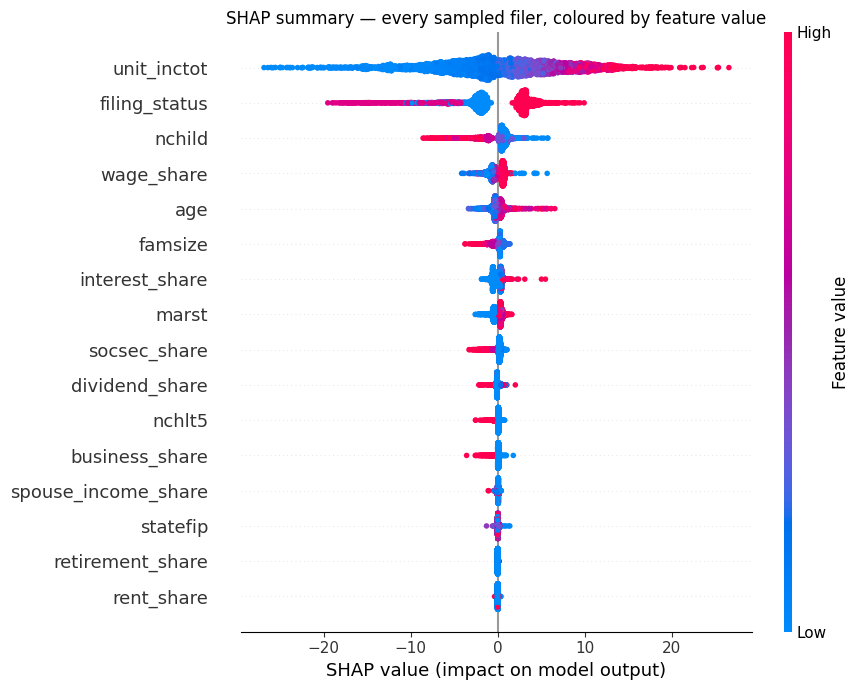

In [4]:
# Beeswarm: the same ranking, but showing the *distribution* and *direction* of
# each feature's effect, coloured by the feature's own value. This is where a
# reader sees "high income pushes rates up" rather than merely "income matters".
expl = shap.Explanation(
    values=shap_collapsed,
    base_values=np.full(len(shap_collapsed), BASELINE),
    data=X_raw[FEATURE_COLS].to_numpy(),
    feature_names=FEATURE_COLS,
)
shap.plots.beeswarm(expl, max_display=16, show=False)
fig = plt.gcf(); fig.set_size_inches(9, 7)
plt.title("SHAP summary — every sampled filer, coloured by feature value")
plt.tight_layout(); fig.savefig(FIGURES / "phase4_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

## Global output 2 — dependence plots (§5.1)

"Where the aggregate equity findings live." Each panel plots a feature's value
against the rate points it contributes, over the sampled filers — the shape of
the relationship the model learned, including non-linearities a coefficient
could not express.

Categorical features are drawn as per-category distributions; continuous ones as
scatter against value.

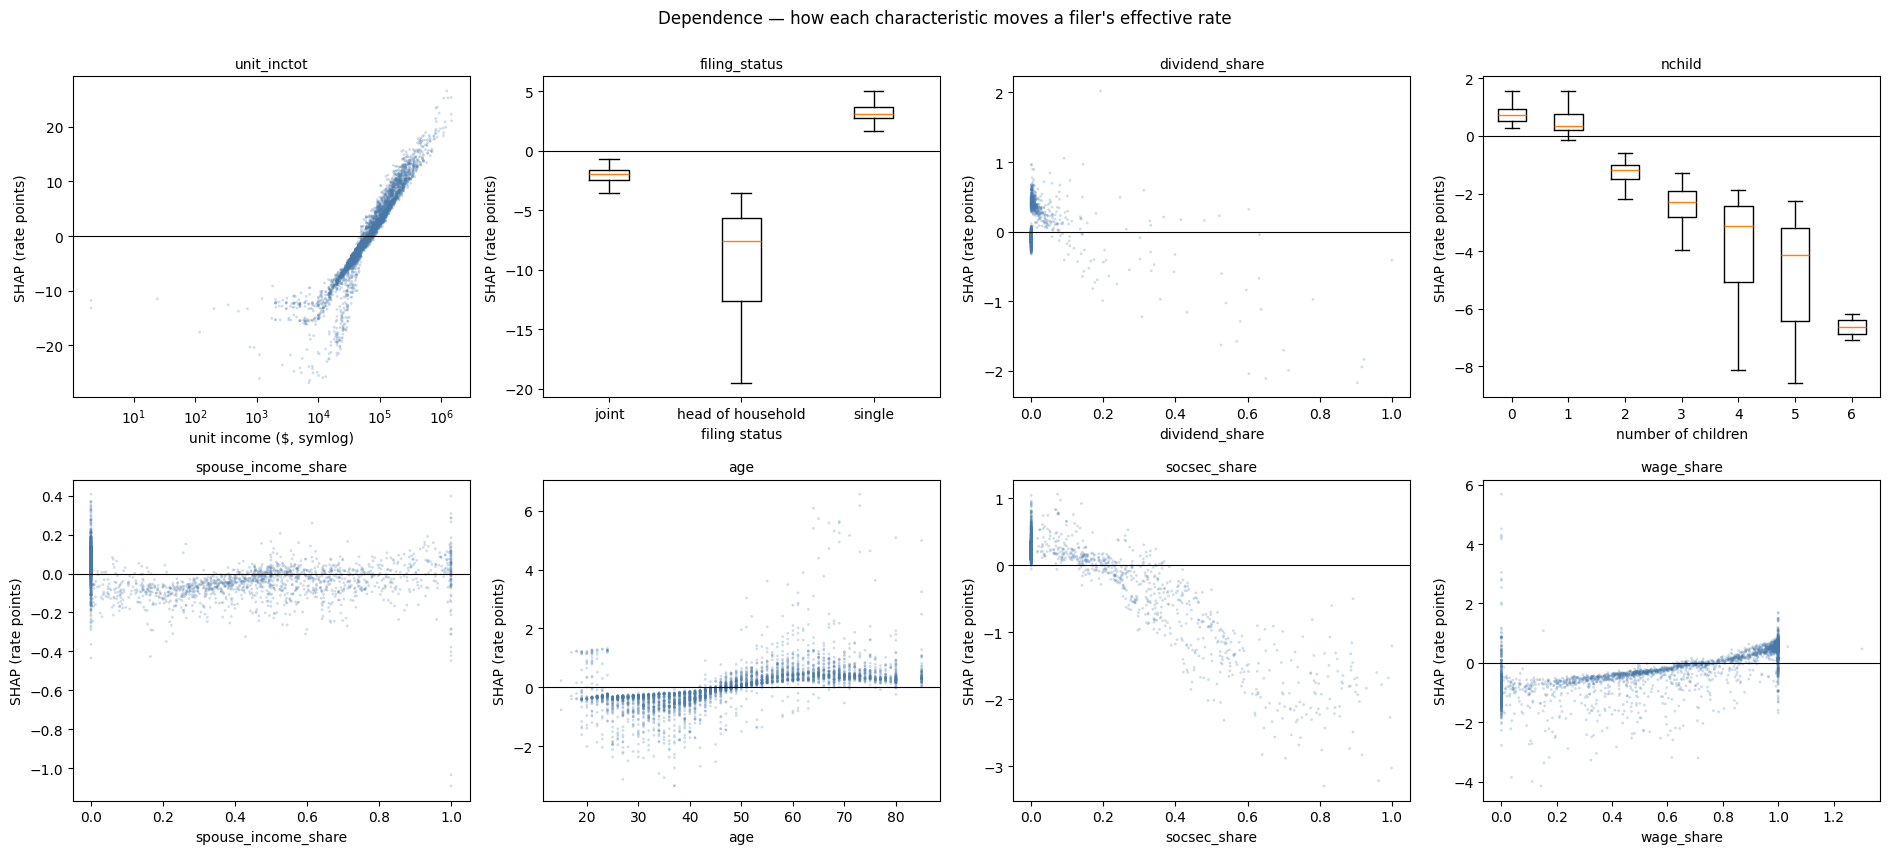

In [5]:
FS_LABEL = {1: "joint", 4: "head of household", 5: "single"}
PANELS = ["unit_inctot", "filing_status", "dividend_share", "nchild",
          "spouse_income_share", "age", "socsec_share", "wage_share"]

fig, axes = plt.subplots(2, 4, figsize=(19, 8.5))
for ax, feat in zip(axes.ravel(), PANELS):
    j = FEATURE_COLS.index(feat)
    x, y = X_raw[feat].to_numpy(), shap_collapsed[:, j]
    if feat == "filing_status":
        groups = [y[x == k] for k in (1, 4, 5)]
        ax.boxplot(groups, tick_labels=[FS_LABEL[k] for k in (1, 4, 5)], showfliers=False)
        ax.set_xlabel("filing status")
    elif feat == "nchild":
        vals = sorted(np.unique(x))[:7]
        ax.boxplot([y[x == v] for v in vals], tick_labels=[int(v) for v in vals], showfliers=False)
        ax.set_xlabel("number of children")
    else:
        if feat == "unit_inctot":
            ax.set_xscale("symlog"); ax.set_xlabel("unit income ($, symlog)")
        else:
            ax.set_xlabel(feat)
        ax.scatter(x, y, s=4, alpha=0.25, color="#4878a8", edgecolors="none")
    ax.axhline(0, color="k", lw=0.8)
    ax.set_ylabel("SHAP (rate points)")
    ax.set_title(feat, fontsize=10)
fig.suptitle("Dependence — how each characteristic moves a filer's effective rate", y=1.0)
fig.tight_layout(); fig.savefig(FIGURES / "phase4_dependence.png", dpi=150); plt.show()

In [6]:
# Aggregate equity cuts: the same SHAP values grouped the way §2 frames the
# question. These are model attributions on sampled test filers -- CPS-derived
# throughout, never blended with IRS figures (§6 two-source discipline).
inc_decile = pd.qcut(X_raw["unit_inctot"], 10, labels=False, duplicates="drop")

by_status = pd.DataFrame({
    "filers": X_raw.groupby(X_raw.filing_status).size(),
    "mean_filing_status_shap": pd.Series(shap_collapsed[:, FEATURE_COLS.index("filing_status")]).groupby(X_raw.filing_status.values).mean(),
    "mean_predicted_rate": pd.Series(predicted).groupby(X_raw.filing_status.values).mean(),
    "mean_actual_rate": pd.Series(actual).groupby(X_raw.filing_status.values).mean(),
})
by_status.index = [FS_LABEL[i] for i in by_status.index]
print("Filing status — mean SHAP contribution and mean rate (rate points):")
print(by_status.round(3).to_string())

by_income = pd.DataFrame({
    "income_from": X_raw.groupby(inc_decile).unit_inctot.min(),
    "income_to": X_raw.groupby(inc_decile).unit_inctot.max(),
    "income_shap": pd.Series(shap_collapsed[:, FEATURE_COLS.index("unit_inctot")]).groupby(inc_decile.values).mean(),
    "capital_shap": pd.Series(shap_collapsed[:, [FEATURE_COLS.index(c) for c in ("dividend_share", "interest_share", "rent_share")]].sum(axis=1)).groupby(inc_decile.values).mean(),
    "children_shap": pd.Series(shap_collapsed[:, [FEATURE_COLS.index(c) for c in ("nchild", "nchlt5")]].sum(axis=1)).groupby(inc_decile.values).mean(),
    "mean_predicted": pd.Series(predicted).groupby(inc_decile.values).mean(),
})
print("\nBy unit-income decile — mean SHAP contribution (rate points):")
print(by_income.round(3).to_string())
by_status.to_csv(SHAP_DIR / "equity_by_filing_status.csv")
by_income.to_csv(SHAP_DIR / "equity_by_income_decile.csv")

Filing status — mean SHAP contribution and mean rate (rate points):
                   filers  mean_filing_status_shap  mean_predicted_rate  mean_actual_rate
joint                1713                   -2.259                6.563             6.643
head of household     352                   -9.168               -8.611            -8.504
single               1935                    3.302                7.250             7.242

By unit-income decile — mean SHAP contribution (rate points):
   income_from  income_to  income_shap  capital_shap  children_shap  mean_predicted
0          2.0    22000.0      -12.522        -0.447          0.645          -6.046
1      22003.0    32661.0       -7.720        -0.362          0.250          -2.097
2      32800.0    42485.0       -4.410        -0.224          0.316           1.568
3      42500.0    52721.0       -2.263        -0.141          0.255           3.343
4      52780.0    67004.0       -0.615        -0.062          0.396           5.548
5    

## Per-filer waterfalls (§5.1)

A waterfall starts at the **baseline** — the average predicted rate across
filers — and walks feature by feature to *this* filer's predicted rate, each bar
showing that feature's signed push in rate points. Because SHAP is additive and
we verified additivity above, the bars close exactly on the prediction.

Two sets are produced, per the logged decision:

* **Equity archetypes** — real test filers selected to carry the §2 argument
  (the same income taxed differently depending on composition and filing status,
  and the refundable-credit tail). Every one is an actual row from `test.csv`;
  none are invented profiles.
* **Random sample** — 8 filers drawn at random from the explained sample, as
  evidence that rendering holds across the distribution rather than only on
  hand-picked cases.

In [7]:
work = X_raw.copy()
work["predicted"], work["actual"] = predicted, actual
work["capital_share"] = work[["dividend_share", "interest_share", "rent_share"]].sum(axis=1)
hi = work.unit_inctot.quantile(0.90)

def pick(mask, sort_by=None, ascending=False):
    sub = work[mask]
    if len(sub) == 0:
        return None
    if sort_by is not None:
        sub = sub.sort_values(sort_by, ascending=ascending)
    return int(sub.index[0])

archetypes = {}
med = work.predicted.median()
archetypes["median filer"] = int((work.predicted - med).abs().idxmin())
archetypes["high income, capital-heavy"] = pick(
    (work.unit_inctot >= hi) & (work.capital_share > 0.2), "capital_share")
archetypes["high income, wage-heavy"] = pick(
    (work.unit_inctot >= hi) & (work.wage_share > 0.9), "unit_inctot", True)
archetypes["negative rate, children"] = pick(
    (work.actual < -5) & (work.nchild >= 2), "actual", True)

# Matched-income single vs joint: the §5.2 twin comparison, but *observed*
# rather than counterfactual -- two real filers. To isolate filing status the
# pair is matched on the other drivers too (same child count, closest income,
# nearest age); differing only in income would leave the gap unattributable.
mid = work[work.unit_inctot.between(40_000, 150_000)]
best = None
for kids in (0, 1, 2):
    s = mid[(mid.filing_status == 5) & (mid.nchild == kids)]
    j = mid[(mid.filing_status == 1) & (mid.nchild == kids)]
    if not len(s) or not len(j):
        continue
    inc_gap = np.abs(s.unit_inctot.to_numpy()[:, None] - j.unit_inctot.to_numpy()[None, :])
    age_gap = np.abs(s.age.to_numpy()[:, None] - j.age.to_numpy()[None, :])
    # income match dominates; age breaks ties between equally close incomes
    cost = inc_gap / max(mid.unit_inctot.median(), 1) + 0.01 * age_gap
    si, ji = np.unravel_index(np.argmin(cost), cost.shape)
    score = cost[si, ji]
    if best is None or score < best[0]:
        best = (score, int(s.index[si]), int(j.index[ji]), kids)
if best is not None:
    _, s_row, j_row, kids = best
    archetypes[f"matched (income, {kids} kids) — single"] = s_row
    archetypes[f"matched (income, {kids} kids) — joint"] = j_row

archetypes = {k: v for k, v in archetypes.items() if v is not None}
print("Selected archetypes (row = position within the explained sample):")
for name, i in archetypes.items():
    r = work.loc[i]
    print(f"  {name:32s} row {i:5d}  income ${r.unit_inctot:>10,.0f}  "
          f"{FS_LABEL[r.filing_status]:<18s} kids {int(r.nchild)}  "
          f"predicted {r.predicted:6.2f}  actual {r.actual:6.2f}")

Selected archetypes (row = position within the explained sample):
  median filer                     row    99  income $    39,305  single             kids 0  predicted   7.00  actual   7.18
  high income, capital-heavy       row  2302  income $ 1,083,339  single             kids 0  predicted  23.39  actual  19.65
  high income, wage-heavy          row  2902  income $   222,632  joint              kids 0  predicted  14.17  actual  14.89
  negative rate, children          row    35  income $     7,000  head of household  kids 4  predicted -41.43  actual -49.64
  matched (income, 0 kids) — single row   703  income $    40,000  single             kids 0  predicted   7.28  actual   7.29
  matched (income, 0 kids) — joint row  2882  income $    40,000  joint              kids 0  predicted  -0.49  actual   3.08


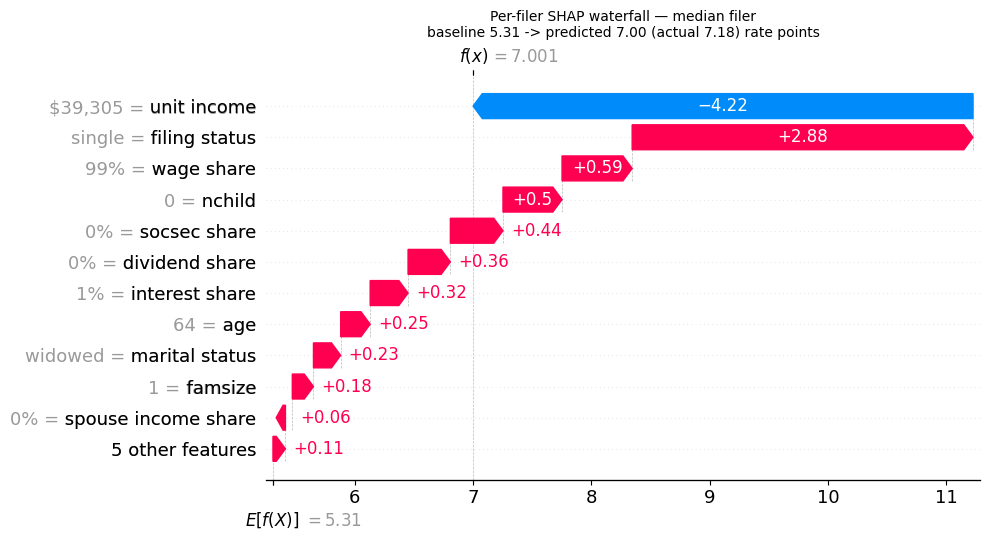

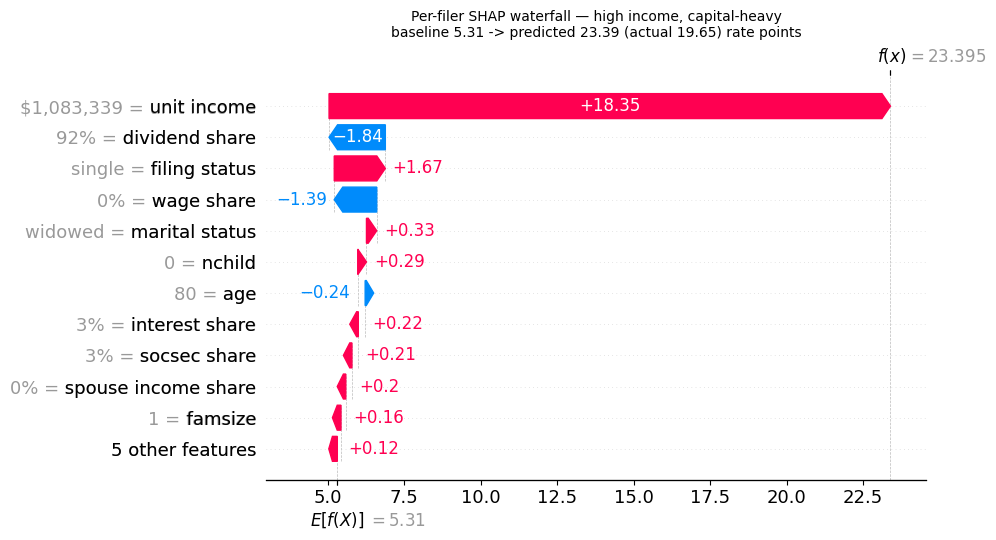

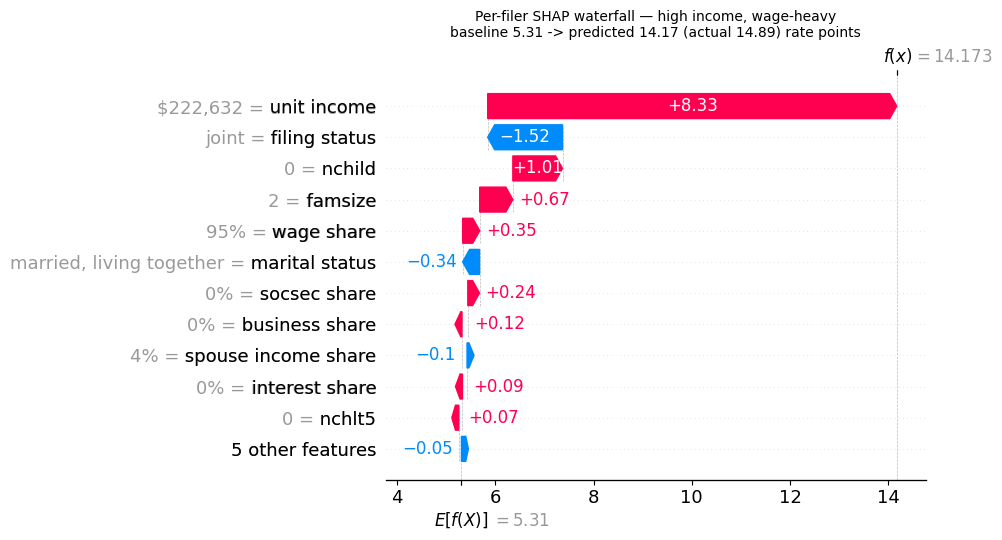

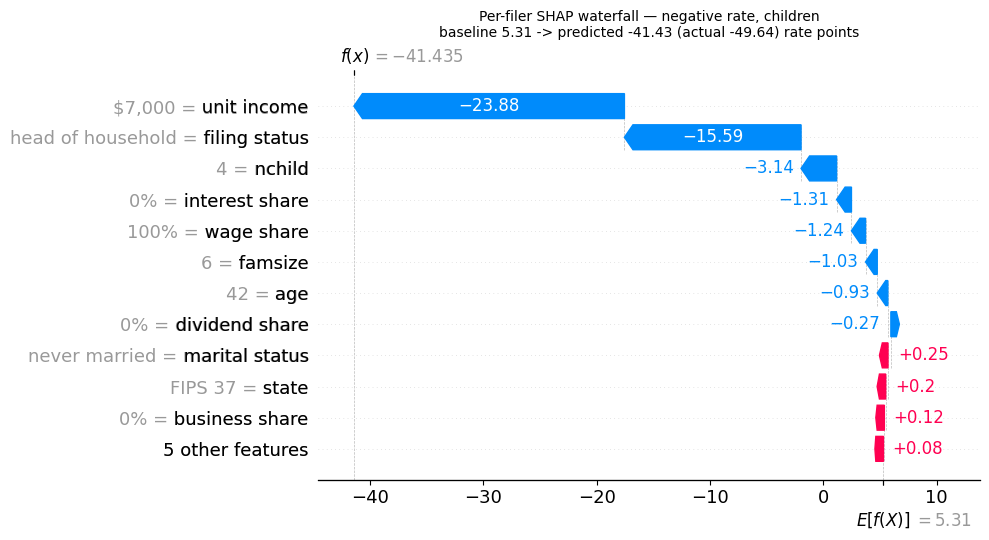

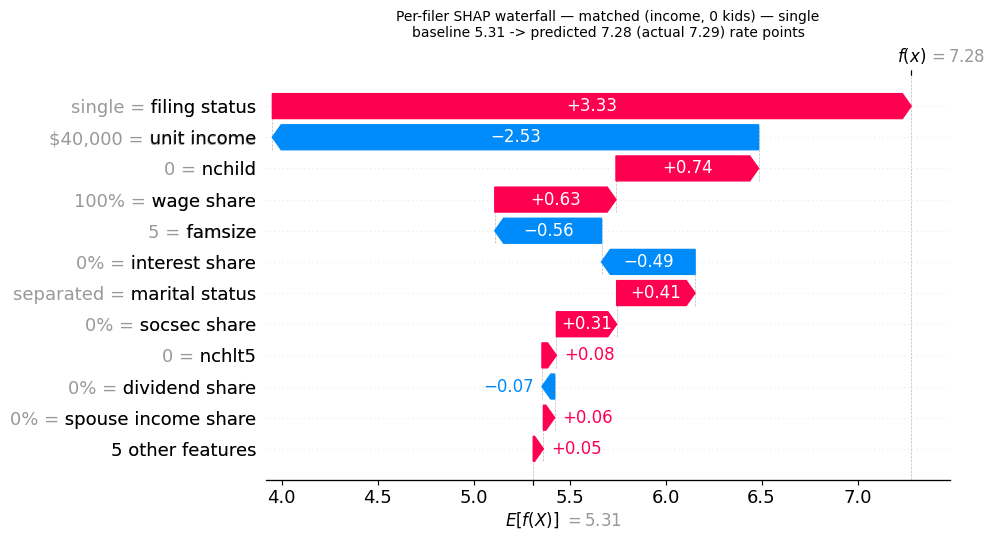

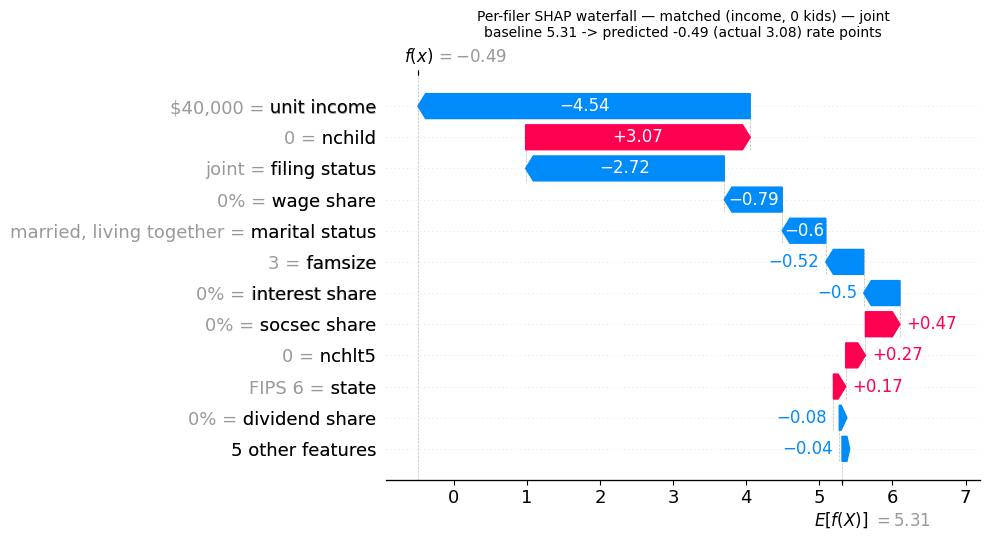

In [8]:
FEATURE_LABEL = {"filing_status": "filing status", "marst": "marital status",
                 "statefip": "state", "unit_inctot": "unit income"}

def feature_label(feature):
    return FEATURE_LABEL.get(feature, feature.replace("_", " "))

def value_label(feature, value):
    if feature == "filing_status": return FS_LABEL[int(value)]
    if feature == "marst":         return mi.MARST_LABELS.get(int(value), int(value))
    if feature == "statefip":      return f"FIPS {int(value)}"
    if feature == "unit_inctot":   return f"${value:,.0f}"
    if feature.endswith("_share"): return f"{value:.0%}"
    if feature in ("nchild", "nchlt5", "famsize", "age"): return f"{int(value)}"
    return f"{value:g}"

def readable(feature, value):
    return f"{feature_label(feature)} = {value_label(feature, value)}"

def waterfall(i, title, path):
    e = shap.Explanation(
        values=shap_collapsed[i],
        base_values=BASELINE,
        data=np.array([value_label(f, X_raw[f].iloc[i]) for f in FEATURE_COLS], dtype=object),
        feature_names=[feature_label(f) for f in FEATURE_COLS],
    )
    shap.plots.waterfall(e, max_display=12, show=False)
    fig = plt.gcf(); fig.set_size_inches(10, 5.5)
    plt.title(f"{title}\nbaseline {BASELINE:.2f} -> predicted {predicted[i]:.2f} "
              f"(actual {actual[i]:.2f}) rate points", fontsize=10)
    plt.tight_layout(); fig.savefig(path, dpi=150, bbox_inches="tight"); plt.show()
    total = BASELINE + shap_collapsed[i].sum()
    assert abs(total - predicted[i]) < 1e-6, "waterfall does not close on the prediction"

for name, i in archetypes.items():
    slug = name.replace(" ", "_").replace(",", "").replace("—", "-")
    waterfall(i, f"Per-filer SHAP waterfall — {name}",
              FIGURES / f"phase4_waterfall_{slug}.png")

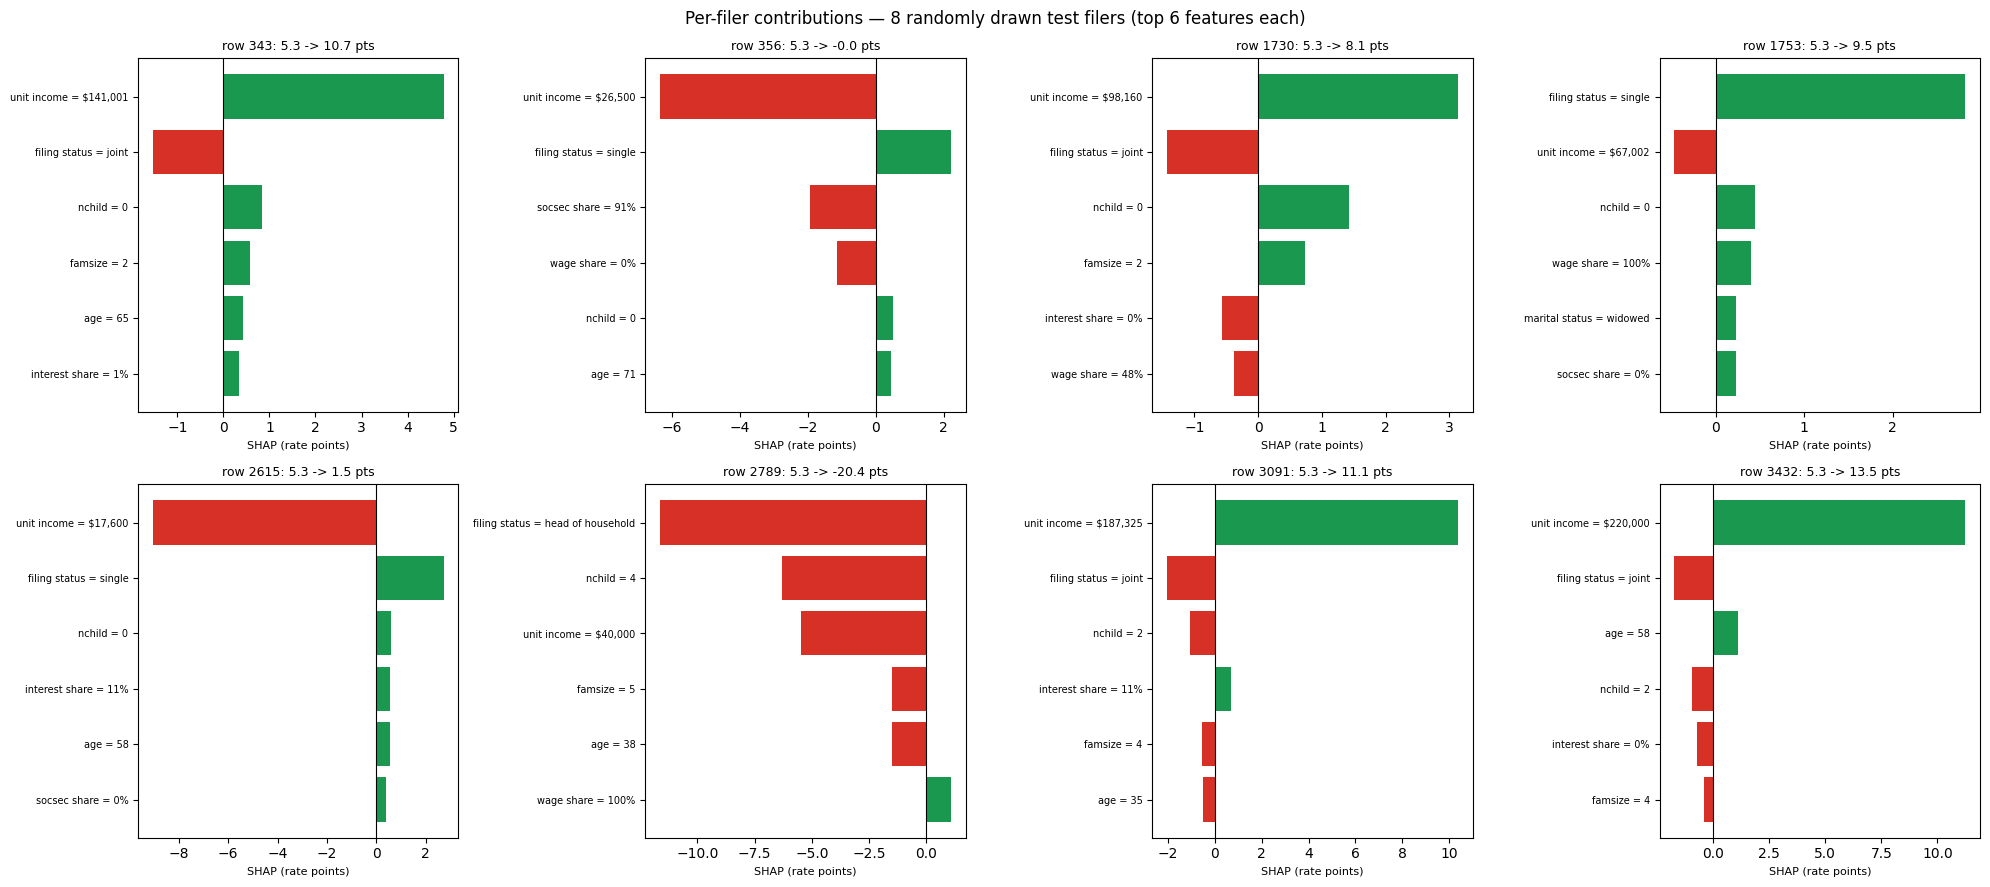

random rows: [343, 356, 1730, 1753, 2615, 2789, 3091, 3432]


In [9]:
# Random sample: rendering must hold across the distribution, not just on
# hand-picked archetypes.
rng = np.random.default_rng(42)
random_rows = sorted(rng.choice(len(X_raw), size=8, replace=False).tolist())
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, i in zip(axes.ravel(), random_rows):
    contrib = pd.Series(shap_collapsed[i], index=FEATURE_COLS)
    top = contrib.reindex(contrib.abs().sort_values(ascending=False).index)[:6][::-1]
    ax.barh(range(len(top)), top.values,
            color=["#d73027" if v < 0 else "#1a9850" for v in top.values])
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels([readable(f, X_raw[f].iloc[i]) for f in top.index], fontsize=7)
    ax.axvline(0, color="k", lw=0.8)
    ax.set_title(f"row {i}: {BASELINE:.1f} -> {predicted[i]:.1f} pts", fontsize=9)
    ax.set_xlabel("SHAP (rate points)", fontsize=8)
fig.suptitle("Per-filer contributions — 8 randomly drawn test filers (top 6 features each)")
fig.tight_layout(); fig.savefig(FIGURES / "phase4_waterfalls_random.png", dpi=150); plt.show()
print("random rows:", random_rows)

## Machine-readable export (logged decision)

Phase 4 emits structured contributions keyed by **feature name**, with signed
rate-point values, a top-K/remainder split, and the additivity invariant
`baseline + sum(reasons) + remainder == predicted`.

It deliberately stops short of prose. The plain-language phrasing the
`components/contribution` fixtures show ("having three children at home") is
stretch goal §8.3 and Phase 7 presentation work; hardcoding wording now would
pre-empt that design. What is emitted is exactly the numeric contract those
components need, with feature names a serializer can map to copy later.

In [10]:
def explanation_record(i, top_k=5):
    contrib = pd.Series(shap_collapsed[i], index=FEATURE_COLS)
    ranked = contrib.reindex(contrib.abs().sort_values(ascending=False).index)
    top, rest = ranked[:top_k], ranked[top_k:]
    return {
        "sample_row": int(i),
        "test_csv_row": int(sample_index[i]),
        "baseline": round(BASELINE, 6),
        "predicted": round(float(predicted[i]), 6),
        "actual": round(float(actual[i]), 6),
        "reasons": [{"feature": f, "value": float(X_raw[f].iloc[i]),
                     "points": round(float(v), 6)} for f, v in top.items()],
        "remainder": round(float(rest.sum()), 6),
        "contributions": {f: round(float(v), 6) for f, v in contrib.items()},
        "profile": {f: float(X_raw[f].iloc[i]) for f in FEATURE_COLS},
    }

export = {
    "phase": 4,
    "spec": "README §5.1 (SHAP TreeExplainer: global summary + per-filer waterfall)",
    "units": "effective-rate percentage points",
    "baseline": round(BASELINE, 6),
    "baseline_meaning": "average predicted effective rate; the start of every waterfall",
    "source": {"data": "data/processed/test.csv (frozen)",
               "sampled_rows": int(len(X_raw)), "random_state": 42,
               "model_metrics": metrics["metrics"]["test"]},
    "global_importance": [
        {"feature": f, "mean_abs_shap_pts": round(float(mean_abs[f]), 6),
         "mean_signed_shap_pts": round(float(mean_signed[f]), 6)}
        for f in summary.index],
    "archetypes": {name: explanation_record(i) for name, i in archetypes.items()},
    "random_sample": [explanation_record(i) for i in random_rows],
}
(SHAP_DIR / "shap_explanations.json").write_text(json.dumps(export, indent=2) + "\n")

for rec in list(export["archetypes"].values()) + export["random_sample"]:
    closed = rec["baseline"] + sum(r["points"] for r in rec["reasons"]) + rec["remainder"]
    assert abs(closed - rec["predicted"]) < 1e-4, f"record {rec['sample_row']} does not close"
print(f"Wrote {(SHAP_DIR / 'shap_explanations.json').relative_to(ROOT)} — "
      f"{len(export['archetypes'])} archetypes + {len(export['random_sample'])} random filers")
print("Every record satisfies baseline + sum(reasons) + remainder == predicted.")
np.save(SHAP_DIR / "shap_values_collapsed.npy", shap_collapsed)
print("Wrote shap_values_collapsed.npy", shap_collapsed.shape)

Wrote reports/shap/shap_explanations.json — 6 archetypes + 8 random filers
Every record satisfies baseline + sum(reasons) + remainder == predicted.
Wrote shap_values_collapsed.npy (4000, 16)


## Definition of Done — Phase 4

- [x] `TreeExplainer` run on the Phase 3 forest; additivity verified to ~1e-12,
      before and after collapsing to source features.
- [x] **Global** feature-importance summary — `global_feature_importance.csv`,
      `phase4_global_importance.png`, `phase4_beeswarm.png`.
- [x] **Global** dependence plots — `phase4_dependence.png`, plus the aggregate
      equity cuts by filing status and income decile.
- [x] **Per-filer** waterfalls, baseline → prediction, one labeled bar per
      feature — archetypes and a random sample.
- [x] Collapse cross-validated against `model_interface._collapse_encoded_contributions`,
      so this analysis and the Streamlit demo describe the same model.
- [x] Machine-readable `shap_explanations.json` with the additivity invariant asserted.

**Not done here, deliberately:** the plain-language wording of contributions
(stretch §8.3) and any UI wiring (Phase 7). Phase 5 (twin comparison) and
Phase 6 (IRS SOI validation) are independent of this notebook and run in
parallel per §9.